In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_df = pd.read_csv("../data/raw/dreaddit-train.csv")
test_df = pd.read_csv("../data/raw/dreaddit-test.csv")

In [4]:
test_df.columns

Index(['id', 'subreddit', 'post_id', 'sentence_range', 'text', 'label',
       'confidence', 'social_timestamp', 'social_karma', 'syntax_ari',
       ...
       'lex_dal_min_pleasantness', 'lex_dal_min_activation',
       'lex_dal_min_imagery', 'lex_dal_avg_activation', 'lex_dal_avg_imagery',
       'lex_dal_avg_pleasantness', 'social_upvote_ratio',
       'social_num_comments', 'syntax_fk_grade', 'sentiment'],
      dtype='str', length=116)

In [5]:
cols_to_keep = ['text', 'label']
train_df = train_df[cols_to_keep]
test_df = test_df[cols_to_keep]

In [6]:
train_df.head()

,text,label
0,"He said he had not felt that way before, sugge...",1
1,"Hey there r/assistance, Not sure if this is th...",0
2,My mom then hit me with the newspaper and it s...,1
3,"until i met my new boyfriend, he is amazing, h...",1
4,October is Domestic Violence Awareness Month a...,1


In [7]:
label_counts = train_df["label"].value_counts()
print(label_counts)

label
1    1488
0    1350
Name: count, dtype: int64


In [8]:
sns.set_theme(style="whitegrid")

C:\Users\rabil\AppData\Local\Temp\ipykernel_3644\3151386195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='label', palette=['#2b5c8f', '#d9534f'])


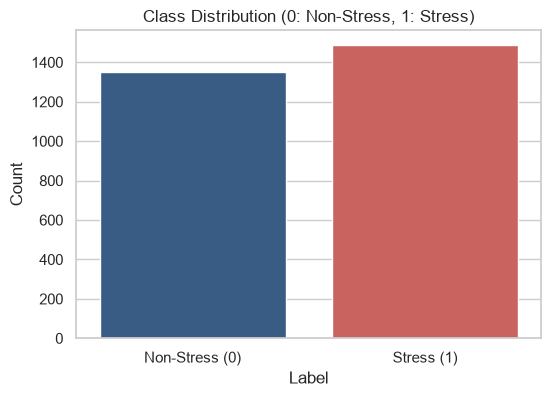

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='label', palette=['#2b5c8f', '#d9534f'])
plt.title("Class Distribution (0: Non-Stress, 1: Stress)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], ['Non-Stress (0)', 'Stress (1)'])
plt.show()

In [10]:
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

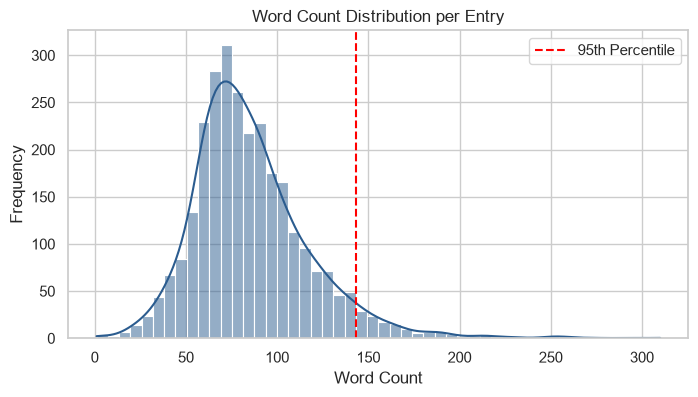

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(data=train_df, x='word_count', bins=50, kde=True, color='#2b5c8f')
plt.title("Word Count Distribution per Entry")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.axvline(train_df['word_count'].quantile(0.95), color='red', linestyle='--', label='95th Percentile')
plt.legend()
plt.show()

# Multilingual Augmentation & Error Handling

In [36]:
from deep_translator import GoogleTranslator
import time

In [37]:
translator = GoogleTranslator(source='auto', target='hi')

In [38]:
def select_translation_subset(df, n):
    
    if not 0 < n <= 100:
        raise ValueError("n must be between 0 and 100.")

    if 'text' not in df.columns or 'label' not in df.columns:
        raise ValueError(
            "DataFrame must contain 'text' and 'label' columns."
        )

    translation_count = round(len(df) * n / 100)

    # Number of samples from each class
    label_0_count = round(
        (df['label'] == 0).sum() * n / 100
    )

    label_1_count = translation_count - label_0_count

    # Sample each class separately
    label_0_sample = df[
        df['label'] == 0
    ].sample(
        n=label_0_count,
        random_state=42
    )

    label_1_sample = df[
        df['label'] == 1
    ].sample(
        n=label_1_count,
        random_state=42
    )

    # Combine samples
    subset = pd.concat(
        [label_0_sample, label_1_sample]
    )

    # Shuffle
    subset = subset.sample(
        frac=1,
        random_state=42
    ).reset_index(drop=True)

    return subset

In [39]:
import random
def translate_with_retry(
    text,
    translator,
    max_retries=5
):
    for attempt in range(max_retries):
        try:
            translated_text = translator.translate(text)
            if (
                translated_text
                and "Error 500" not in translated_text
                and "HTTP Error" not in translated_text
            ):
                return translated_text
        except Exception as e:
            print(
                f"\nAttempt {attempt + 1}/{max_retries} failed: "
                f"{str(e)[:80]}"
            )
        # Exponential backoff
        wait_time = min(2 ** attempt, 16)
        wait_time += random.uniform(0, 1)
        time.sleep(wait_time)
    return None

In [40]:
def translate_dataframe(subset, translator):
    translated_records = []
    success_count = 0
    fail_count = 0
    total = len(subset)

    for idx, row in subset.iterrows():
        orig_text = str(row['text'])
        label = row['label']

        # Limit very long texts
        query_text = orig_text[:400]

        translated_text = translate_with_retry(
            query_text,
            translator
        )
        if translated_text is None:

            fail_count += 1
        else:
            translated_records.append({
                'text': translated_text,
                'label': label
            })
            success_count += 1
        print(
            f"Progress: {success_count + fail_count}/{total} "
            f"| Success: {success_count} "
            f"| Failed: {fail_count}",
            end="\r"
        )

        # Normal request throttle
        time.sleep(0.7)

    print("\n")
    hindi_df = pd.DataFrame(translated_records)
    return hindi_df, success_count, fail_count

In [41]:
def remove_duplicate_texts(df):
    return df.drop_duplicates(
        subset='text',
        keep='first'
    ).reset_index(drop=True)

In [42]:
def translate_subset(df, n):
    print("=" * 50)
    print("STARTING TRANSLATION")
    print("=" * 50)

    # Step 1: Select subset
    subset = select_translation_subset(df, n)

    print(f"\nOriginal dataframe: {len(df)} rows")
    print(f"Percentage selected: {n}%")
    print(f"Rows selected: {len(subset)}")

    print("\nSelected class distribution:")
    print(subset['label'].value_counts())

    # Step 2: Translate
    print("\nStarting translation...")

    final_df, success_count, fail_count = translate_dataframe(
        subset,
        translator
    )

    # Step 3: Remove duplicates
    before_duplicates = len(final_df)

    final_df = remove_duplicate_texts(final_df)

    duplicates_removed = (
        before_duplicates - len(final_df)
    )

    # Step 4: Final information
    print("=" * 50)
    print("TRANSLATION COMPLETED")
    print("=" * 50)

    print(f"Rows selected: {len(subset)}")
    print(f"Successful translations: {success_count}")
    print(f"Failed translations: {fail_count}")
    print(f"Duplicates removed: {duplicates_removed}")
    print(f"Final Hindi rows: {len(final_df)}")

    print("\nFinal class distribution:")
    print(final_df['label'].value_counts())

    return final_df

In [43]:
hindi_df = translate_subset(train_df, 20)

STARTING TRANSLATION

Original dataframe: 2838 rows
Percentage selected: 20%
Rows selected: 568

Selected class distribution:
label
1    298
0    270
Name: count, dtype: int64

Starting translation...


KeyboardInterrupt: 

In [ ]:
hindi_val_df = translate_subset(test_df, n=25)

STARTING TRANSLATION

Original dataframe: 715 rows
Percentage selected: 25%
Rows selected: 179

Selected class distribution:
label
1    93
0    86
Name: count, dtype: int64

Starting translation...
Progress: 179/179 | Success: 147 | Failed: 32

TRANSLATION COMPLETED
Rows selected: 179
Successful translations: 147
Failed translations: 32
Duplicates removed: 0
Final Hindi rows: 147

Final class distribution:
label
0    75
1    72
Name: count, dtype: int64


In [ ]:
hindi_train_df = hindi_df
del hindi_df

In [ ]:
train_df_processed = pd.concat([train_df[['text', 'label']], hindi_train_df], ignore_index=True)
val_df_processed = pd.concat([test_df[['text', 'label']], hindi_val_df], ignore_index=True)

In [ ]:
train_df_processed = train_df_processed.sample(frac=1.0, random_state=42).reset_index(drop=True)
val_df_processed = val_df_processed.sample(frac=1.0, random_state=42).reset_index(drop=True)


In [ ]:
TRAIN_PROCESSED_PATH = "../data/processed/train.csv"
VAL_PROCESSED_PATH = "../data/processed/val.csv"

In [ ]:
train_df_processed.to_csv(TRAIN_PROCESSED_PATH, index=False)
val_df_processed.to_csv(VAL_PROCESSED_PATH, index=False)